# Applied Deep Learning 2026 - "Exercise 0" - Introduction to Colab and some useful python skills

The excercises in this seminar are designed to work well in the Google Colab environments. You are free to run them on your local computer or another platform of your choice of course.

As first step in *every* exercise, create a copy of every notebook for yourself with "File -> Save a copy in Drive".

When you execute the first code cell in the notebooks of the exercises, Colab will ask you, whether this is safe. You can happily click "Run anyway" because you trust your lecturers of course ;)

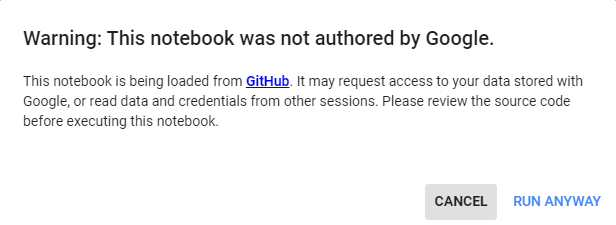

Google Colab essentiall works exactly like a Jupyter Notebook, which probably some of you are already familiar with. You can write and execute Python code interactively in every cell. The results are kept in memory until you restart the environment. Many Python packages like `numpy` or `scipy` are already preinstalled:

In [1]:
import numpy as np

x = np.linspace(0, 2*np.pi, 100) # create 100 linearly spaced numbers from 0 to 2*pi
y = np.sin(x) # compute the sine of those values

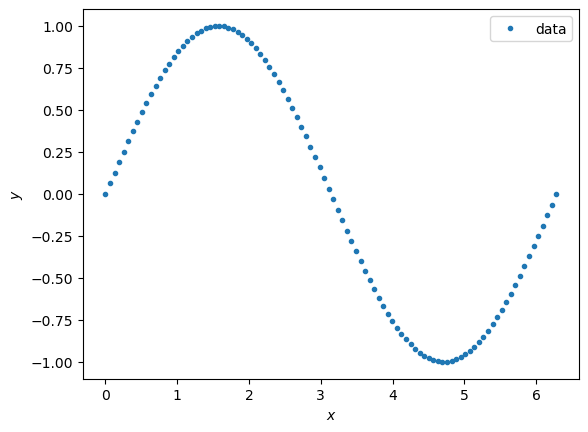

In [2]:
import matplotlib.pyplot as plt

plt.plot(x, y, '.', label='data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend(loc='best'); # remove the `;` to see what changes
# you do not need to execute plt.show() in notebooks, the plot should appear anyway.

### Excersice 0: Hints
If you put the cursor inside of the brackets of a function, what happens if you hit `Shift+Tab` and then type anything (like a space or comma)? What about `Ctrl+Space`?

In [3]:
print('hello world')


hello world


`Shift+Tab` is used to outdent code, and for me it is not doing anything different when the cursor is inside of the brackets of a function. In this case, if you want to see the documentation of the function as you write inside the brackets, you can use `Ctrl+Shift+Space`. If you write a comma, the next expected parameter is highlighted.

If you press `Ctrl+Space` with the cursor inside of the brackets of a function, you see a list of suggestions (like arguments or keyword arguments) to complete your code.

# Python packages used throughout the course

The most important Python packages, besides the machine learning libraries we will use ([`scikit-learn`](https://scikit-learn.org/stable/) and [`tensorflow`/`keras`](https://www.tensorflow.org/api_docs)), are certainly [`numpy`](https://numpy.org/doc/stable/contents.html), [`matplotlib`](https://matplotlib.org/stable/index.html) and [`pandas`](https://pandas.pydata.org/docs/index.html). Additionally, [`seaborn`](https://seaborn.pydata.org/) is a very use- and powerful visualization library.

# <a href=https://numpy.org><img src="https://numpy.org/images/logo.svg" width=50 align=center>numpy</a> refresher
If you do not already know, you will learn that the world of machine learning is full of vectors and matrices. In Python, `numpy` is the tool of choice to handle those.


In [4]:
vec = np.array([1,2,3,4,5,6])
print(vec)

[1 2 3 4 5 6]


In [5]:
print('Shape of vec:', vec.shape)
print('Size of vec:', vec.size)
print('Dimension of vec:', vec.ndim)

Shape of vec: (6,)
Size of vec: 6
Dimension of vec: 1


In machine learning frameworks it is common, that both the design matrix `X` (the data we want to use for training) and the target vector `y` (the labels or whatever we want to predict as goal of the training) are expected in the form `SxF` (S,F) where `S` are the samples and `F` are the features.

In many cases, especially the target `y` has the shape like the vector we just created `(S,)`, in our case `(6,)`. This means, as you can see from the output of `vec.ndim`, that the vector is one-dimensional. There are two commonly used ways to change this to match the expected form for machine learning libraries:

In [6]:
# reshape the existing vector into a SxF matrix
y = vec.reshape(6, 1)
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


In [7]:
# create a new dimension to transform the vector into a matrix
y = vec[:, np.newaxis]
print('y:', y)
print('Shape of y:', y.shape)
print('Size of y:', y.size)
print('Dimension of y:', y.ndim)

y: [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Shape of y: (6, 1)
Size of y: 6
Dimension of y: 2


### Exercise 1: Row or column vector?

A common task in the background for machine learning are vector and matrix multiplications. Inspect the following commands. Which ones work, which ones give errors? If there is an error, why does it occur? If it works, what do they compute? What is a row vector, what a column vector in numpy? And what is the difference between those two anyway?

- `a = vec.reshape(-1, 1)`
- `b = vec.reshape(1, -1)`
- `c = vec.reshape(2, 3)`
- `d = vec.reshape(-1, 3)`
- `d = vec.reshape(-1, -1)`
- `e = vec[..., np.newaxis]`
- `f = c[:, np.newaxis]`
- `g = c[np.newaxis, :, :]`
- `h = c[np.newaxis, ...]`
- `i = np.dot(vec, vec)`
- `j = vec @ vec`
- `k = vec.T`
- `l = a.T`
- `m = np.dot(a, vec)`
- `n = c @ d`
- `o = c.T @ d`
- `p = c @ d.T`
- `q = c @ d.T @ c`
-` r = np.dot(c, d.T)`
- `s = np.matmul(c, d.T)`
- `t = np.dot(c, 4)`
- `u = np.dot(4, c)`
- `v = 4*c`


In numpy, the difference between row and column vectors only makes sense when they are in the form of 2-dimensional matrices. A $1\times N$ matrix is a row vector and a $N\times1$ vector is a column vector.

In [8]:
a = vec.reshape(-1, 1)
print(a)
print(a.shape)

[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
(6, 1)


In [9]:
b = vec.reshape(1, -1)
print(b)
print(b.shape)

[[1 2 3 4 5 6]]
(1, 6)


In [10]:
c = vec.reshape(2, 3)
print(c)
print(c.shape)

[[1 2 3]
 [4 5 6]]
(2, 3)


In [11]:
d = vec.reshape(-1, 3)
print(d)
print(d.shape)

[[1 2 3]
 [4 5 6]]
(2, 3)


`vec.reshape(d1, d2)` reshapes the vector `vec` into a $d_1\times d_2$ matrix. This shape needs to be compatible with the original size. If one of the dimensions is set to $-1$, it is inferred from the remaining dimension.

In [12]:
d = vec.reshape(-1, -1)

ValueError: can only specify one unknown dimension

In this case, both dimensions are set to $-1$, so they cannot be inferred. As the error says, you can only specify one unknown dimension.

In [13]:
e = vec[..., np.newaxis]
print(e)
print(e.shape)

[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
(6, 1)


This adds one axis as the last dimension to the vector `vec`, resulting in a $6\times1$ matrix.

In [14]:
f = c[:, np.newaxis]
print(f)
print(f.shape)

[[[1 2 3]]

 [[4 5 6]]]
(2, 1, 3)


This adds one axis after the first dimension to the matrix `c`, converting the $2\times3$ matrix in a $2\times1\times3$ array.



In [15]:
g = c[np.newaxis, :, :]
print(g)
print(g.shape)

[[[1 2 3]
  [4 5 6]]]
(1, 2, 3)


This adds one axis as the first dimension to the matrix `c`, converting the $2\times3$ matrix in a $1\times2\times3$ array.

In [16]:
h = c[np.newaxis, ...]
print(h)
print(h.shape)

[[[1 2 3]
  [4 5 6]]]
(1, 2, 3)


The result is the same as `g`. In this case, we used `...` to slice the last 2 dimensions of `c`, instead of using `:` twice.

In [17]:
i = np.dot(vec, vec)
print(i)

91


In [18]:
j = vec @ vec
print(j)

91


In both cases, the command computes the scalar product of `vec` with itself.

In [19]:
k = vec.T
print(k)
print(k.shape)

[1 2 3 4 5 6]
(6,)


Nothing happens because there is only one dimension, so the array cannot be transposed.

In [20]:
l = a.T
print(l)
print(l.shape)

[[1 2 3 4 5 6]]
(1, 6)


The $6\times1$ column vector is transposed to get a $1\times6$ row vector.

In [21]:
m = np.dot(a, vec)

ValueError: shapes (6,1) and (6,) not aligned: 1 (dim 1) != 6 (dim 0)

  `a` is $6\times1$ and `vec` is a 1-dimensional array of lenght $6$. The matrix product cannot be computed because the last dimension of `a` does not match the first dimension of `vec`.

In [22]:
n = c @ d

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

Both `c` and `d` are $2\times3$, so the matrix product cannot be computed.

In [23]:
o = c.T @ d
print(o)
print(o.shape)

[[17 22 27]
 [22 29 36]
 [27 36 45]]
(3, 3)


Now we are transposing the matrix `c` first. A $3\times2$ matrix gets multiplied with a $2\times3$ matrix, resulting in a $3\times3$ matrix.

In [24]:
p = c @ d.T
print(p)
print(p.shape)

[[14 32]
 [32 77]]
(2, 2)


Here we are transposing the matrix `d`. A $2\times3$ matrix gets multiplied with a $3\times2$ matrix, resulting in a $2\times2$ matrix.

In [25]:
q = c @ d.T @ c
print(q)
print(q.shape)

[[142 188 234]
 [340 449 558]]
(2, 3)


Matrix multiplication of $2\times3$ times $3\times2$ times $2\times3$, producing a $2\times3$ matrix.

In [26]:
r = np.dot(c, d.T)
print(r)
print(r.shape)

[[14 32]
 [32 77]]
(2, 2)


In [27]:
s = np.matmul(c, d.T)
print(s)
print(s.shape)

[[14 32]
 [32 77]]
(2, 2)


Both give the same result as `p`. For 2-dimensional matrices, `@`, `np.dot` and `np.matmul` give the same result.

In [28]:
t = np.dot(c, 4)
print(t)
print(t.shape)

[[ 4  8 12]
 [16 20 24]]
(2, 3)


In [29]:
u = np.dot(4, c)
print(u)
print(u.shape)

[[ 4  8 12]
 [16 20 24]]
(2, 3)


In [30]:
v = 4*c
print(v)
print(v.shape)

[[ 4  8 12]
 [16 20 24]]
(2, 3)


The three commands multiply the matrix `c` by the scalar 4. I this context, `np.dot` and the operator `*` work the same way.

## Excercise 2: Creating arrays

There are many ways to create arrays in numpy. Find out what the following do, what arguments they take and create some arrays with them:
- `np.zeros( ... )`
- `np.zeros_like( ... )`
- `np.ones( ... )`
- `np.ones_like( ... )`
- `np.eye( ... )`
- `np.linspace( ... )`
- `np.logspace( ... )`
- `np.arange( ... )`

In [31]:
print(np.zeros((2,3)))

[[0. 0. 0.]
 [0. 0. 0.]]


In [32]:
print(np.zeros_like(f))

[[[0 0 0]]

 [[0 0 0]]]


In [33]:
print(np.ones((2,3)))

[[1. 1. 1.]
 [1. 1. 1.]]


In [34]:
print(np.ones_like(f))

[[[1 1 1]]

 [[1 1 1]]]


`np.zeros` creates an array full of zeros of the specified shape. `np.zeros_like` creates an array full of zeros of the same shape as the array used as argument.

`np.ones`and `np.ones_like` are analogous, but the created array is full of ones.

In [35]:
print(np.eye(3))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


It creates the $d\times d$ identity matrix, where $d$ is the specified dimension.

In [36]:
print(np.linspace(0, 1, 11))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


`np.linspace(p,q,n)` creates an array of $n$ evenly spaced numbers from $p$ to $q$.

In [37]:
print(np.logspace(0, 1, 11))

[ 1.          1.25892541  1.58489319  1.99526231  2.51188643  3.16227766
  3.98107171  5.01187234  6.30957344  7.94328235 10.        ]


`np.logspace(p,q,n)` creates an array of $n$ evenly spaced numbers on a logarithmic scale from $10^p$ to $10^q$. `np.logspace(p,q,n)` is the same as `10**np.linspace(p,q,n)`.

In [38]:
np.arange(0, 1, 0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

`np.arange(p,q,r)` creates an array of numbers spaced by $r$, starting by $p$ and up to $q$ (not included).

## Exercise 3: Indexing and masking

You will in many cases not want to use all values from an array/vector/matrix. To select only some of them, you need to find a way to adress only those values.
1. Create a matrix using the command `mat = np.arange(105).reshape(3, 5, 7)`. Describe the result. How many dimensions does it have, what is its shape, what is its minimum and maximum value.
2. Run the following commands and inspect the results. What do the commands do, how do they work? If there are errors, why do they occur? It can be helpful to display the matrix `mat` as well to see what's going on:
  - `mat[2, 1, 6]`
  - `mat[:, 0, 0]`
  - `mat[:, 2, 4]`
  - `mat[:, 4, :]`
  - `mat[:, :, 7]`
  - `mat[..., 5]`
  - `mat[ mat > 25 ]`
  - `mat[ mat > 25 ].shape`
  - `mat[ (mat > 25) & (mat < 50) ]`
  - `mat[ (mat > 25) and (mat < 50) ]`
  - `mat[ (mat < 10) | (mat > 90) ]`
  - `np.where( mat > 100 )`
  - `np.where( mat < 50, 0, mat)`
  - `np.where( mat < 50, 0, 1)`
  - `mat [ mat < 50 ] = -1`
  - `mat [ np.where(mat < 50) ] = -1`



In [39]:
mat = np.arange(105).reshape(3, 5, 7)
print(mat)
print(mat.shape)
print('min = ', np.min(mat))
print('max = ', np.max(mat))

[[[  0   1   2   3   4   5   6]
  [  7   8   9  10  11  12  13]
  [ 14  15  16  17  18  19  20]
  [ 21  22  23  24  25  26  27]
  [ 28  29  30  31  32  33  34]]

 [[ 35  36  37  38  39  40  41]
  [ 42  43  44  45  46  47  48]
  [ 49  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]
(3, 5, 7)
min =  0
max =  104


It is a $3\times5\times7$ (3-dimensional) matrix with the numbers from 0 to 104.

In [40]:
print(mat[2, 1, 6])

83


Selects element $(2,1,6)$.

In [41]:
print(mat[:, 0, 0])

[ 0 35 70]


Selects all elements with second and third index equal to 0, resulting in an array of lenght 3.

In [42]:
print(mat[:, 2, 4])

[18 53 88]


Same as before, but different indices.

In [43]:
print(mat[:, 4, :])

[[ 28  29  30  31  32  33  34]
 [ 63  64  65  66  67  68  69]
 [ 98  99 100 101 102 103 104]]


Selects all elements with second index equal to 4, resulting in a $3\times7$ matrix.

In [44]:
print(mat[:, :, 7])

IndexError: index 7 is out of bounds for axis 2 with size 7

The third index ranges from 0 to 6, so 7 is out of bounds.

In [45]:
print(mat[..., 5])

[[  5  12  19  26  33]
 [ 40  47  54  61  68]
 [ 75  82  89  96 103]]


Selects all elements with third index equal to 5, resulting in a $3\times5$ matrix. While `:` have to be specified for each index, `...` applies directly to all the dimensions that are not specified (in this case the first and the second indices).

In [46]:
print(mat[ mat > 25 ])

[ 26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104]


In [47]:
print(mat[ mat > 25 ].shape)

(79,)


Selects all elements with a value greater than 25. The result is a 1-dimensional array containing the selected elements (79 in this case).

In [48]:
print(mat[ (mat > 25) & (mat < 50) ])

[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]


Selects all elements whith value greater than 25 and smaller than 50.

In [49]:
print(mat[ (mat > 25) and (mat < 50) ])

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

It does not work because the operator `and` acts on single values, while here we want the condition to be applied element-wise. We get this by using the `&`operator, as done before.

In [50]:
print(mat[ (mat < 10) | (mat > 90) ])

[  0   1   2   3   4   5   6   7   8   9  91  92  93  94  95  96  97  98
  99 100 101 102 103 104]


It selects all elements with value lower than 10 or greater than 90.

In [51]:
print(np.where( mat > 100 ))

(array([2, 2, 2, 2]), array([4, 4, 4, 4]), array([3, 4, 5, 6]))


It returns the set of indices of the elements with value greater than 100. They come in a tuple of arrays, where each array corresponds to one of the dimensions of the matrix (3 in this case). The lenght of the arrays is the number of elements in the matrix that satisfied the condition.

In [52]:
print(np.where( mat < 50, 0, mat))

[[[  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]]

 [[  0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0]
  [  0  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]


It returns a new matrix, where the elements that were lower than 50 are changed to 0 while the others stay the same.

In [53]:
print(np.where( mat < 50, 0, 1))

[[[0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0]
  [0 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]]

 [[1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1]]]


In this case, the elements that were lower than 50 are changed to 0 and the others are also changed to 1.

In [54]:
mat [ mat < 50 ] = -1
print(mat)

[[[ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]]

 [[ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]


The commands in this section up to the last one did not change the matrix `mat`, they just selected a part of it or created a new matrix from it. Now, the matrix is being modified. The elements that were lower than 50 are set to -1.

In [55]:
# Restart the matrix
mat = np.arange(105).reshape(3, 5, 7)

In [56]:
mat [ np.where(mat < 50) ] = -1
print(mat)

[[[ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]]

 [[ -1  -1  -1  -1  -1  -1  -1]
  [ -1  -1  -1  -1  -1  -1  -1]
  [ -1  50  51  52  53  54  55]
  [ 56  57  58  59  60  61  62]
  [ 63  64  65  66  67  68  69]]

 [[ 70  71  72  73  74  75  76]
  [ 77  78  79  80  81  82  83]
  [ 84  85  86  87  88  89  90]
  [ 91  92  93  94  95  96  97]
  [ 98  99 100 101 102 103 104]]]


We are indexing with `np.where(mat<50)` (that returns a set of indices) instead of using the mask `mat<50` directly, but the result is the same as in the previous one.

## Exercise 4: Random numbers and statistics

Numpy also has many functions for random number generation and statistics.
1. Look up the following functions and experiment with them to see how they work:
  - `np.random.uniform( ... )`
  - `np.random.normal( ... )`
  - `np.random.poisson( ... )`
  - `np.random.choice( ... )`
  - `np.random.shuffle( ... )`

2. More tasks with random numbers:
  - what is wrong with this: `a = np.random.shuffle(b)`
  - look up the function `plt.hist( ... )` and show histograms of a Gaussian and a normal distribution. What can you do with the parameters `range`, `bins`, `alpha`, `density`, `histtype`, `stacked`?
  - create a matrix `A` of shape (5, 4, 3, 2, 1) of Gaussian distributed values
  - what does `A.mean()` do? What does `A.mean(axis=(1,3,2))` do?
  - Does `A.std()` compute a sample or population standard deviation? What is the difference between them?
  - create another matrix `B = np.ones(shape=(6, 8, 10))`. Execute the following: `B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))`. What is the result? What happend here? In what real situations would you use `mean` here, when `sum`?


In [57]:
print(np.random.uniform(0, 1, 10))

[0.40690511 0.99022494 0.25375957 0.69309813 0.49264223 0.748864
 0.57935154 0.32669748 0.39572787 0.34049015]


`np.random.uniform(min, max, N)` creates $N$ samples of a uniform distribution $U(0,1)$.

In [58]:
print(np.random.normal(0, 1, 10))

[ 0.8761903   0.10455383  0.49736961  0.64267867  0.63259066  0.86820536
 -1.59678106 -0.88872926 -0.62011699  1.5165079 ]


`np.random.normal(mu, sigma, N)` creates $N$ samples of a normal distribution $N(\mu,\sigma)$.

In [59]:
print(np.random.poisson(7, 10))

[ 7  3  6  8  5  6  3 10  8  5]


`np.random.uniform(lambda, N)` creates $N$ samples of a Poisson distribution $P(\lambda)$.

In [60]:
print(np.random.choice(np.arange(100), 10))

[38 85 51 78 95 78 70 95  5  5]


`np.random.choice(a, N)` randomly choses $N$ elements of tha array `a`.

In [61]:
a = np.arange(100)
np.random.shuffle(a)
print(a)

[62 99 96 39 34 22 57 59 94 74 52 78  9 97 77 36  8 29 66 48 35 82 89 17
 19 10 87 86 13 14 58 16 44 51 23 45 61  5  3 32 83 15 85 68 90  7 81 88
 40 26 37 24 84 50 53  6 63 75 70 41 65 71 72 25 46 92 73  2 69 64  0  1
 11 20 31 18 79 38 60 27 21 93 30 95 42 56 55 28 47 80 33 43 12 49 54  4
 67 91 76 98]


`np.random.shuffle(a)` randomly shuffles the array `a`, modifying it.

In [62]:
b = np.arange(100)
a = np.random.shuffle(b)
print(a)
print(b)

None
[39 96 18 20 30 22 47 66 56 15 99 26 10 89 79 37 43 93 35  1 78  3 60 14
 33 19 71 36 17  6  9 51 40 70 69 44 88 41 12 32 82 11 23 87 81 92 68 91
 21 31 29 97 73 50 48  0 58  8 76 67 94  4 52 84 85 49 98 59 34 45 13 90
  5 86 61 27 62 42 77 54 46 25 74 38  2 57  7 16 64 75 80 83 55 28 65 24
 72 53 95 63]


`np.random.shuffle` always returns `None`. The shuffled array overwrites the original array (`b` in this case).

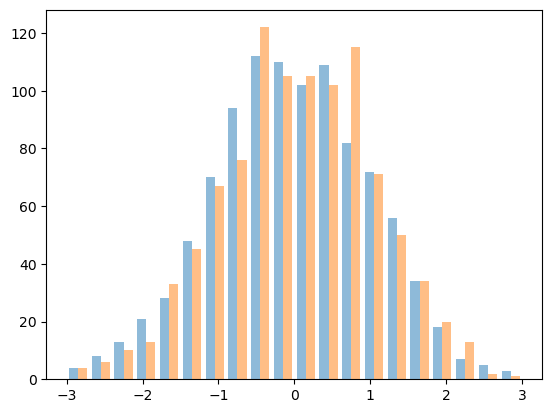

In [63]:
a = np.random.normal(0, 1, 1000)
b = np.random.normal(0, 1, 1000)
plt.hist((a, b), range=(-3, 3), bins=20, alpha=0.5, density=False, histtype='bar', stacked=False);


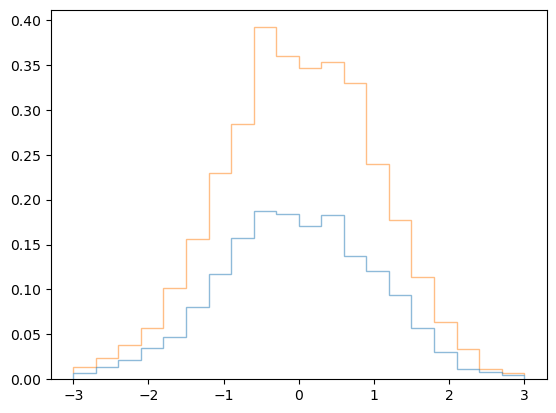

In [64]:
plt.hist((a, b), range=(-3, 3), bins=20, alpha=0.5, density=True, histtype='step', stacked=True);

Here we plotted two histograms of random distributions.
- `range`: sets the range of the histogram. The datapoints out of this range are ignored.
- `bins`: sets the number of bins (you can also specify the edges of the bins).
- `alpha`: transparency of the plot.
- `density`: when set to `True`, the histogram is normalized so the sum of the bins is 1.
- `histtype`: the style of the histogram can be changed.
- `stacked`: when set to `True`, the different histograms are displayed one on top of each other, and the normalization is computed considering all histograms together.


In [65]:
A = np.random.normal(0, 1, (5, 4, 3, 2, 1))

In [66]:
print(A.mean())
print(A.mean(axis=(1,3,2)))

0.023183975977044424
[[-0.09568282]
 [ 0.04446978]
 [-0.0252387 ]
 [ 0.03722364]
 [ 0.15514798]]


`A.mean()` computes the average value of the matrix `A`. `A.mean(axis=(1,3,2))` computes the mean over the second, fourth and third axis (`axis=0` corresponds to the first axis), resulting in a $5\times1$ column vector. It sums over those axis and then divides the product of its sizes. The order of the axis does not matter.

In [67]:
print(A.std())

# Compare to sample and population standard deviation
sample_std = np.sqrt(np.sum((A-A.mean())**2)/(A.size-1))
print('sample:', sample_std==A.std())
pop_std = np.sqrt(np.mean((A-A.mean())**2))
print('population:', pop_std==A.std())

1.1242832721378038
sample: False
population: True


By default, `np.std()` computes the population standard deviation.

In [68]:
B = np.ones(shape=(6, 8, 10))
B_rebin = B.reshape(3, 2, 4, 2, 5, 2).mean(axis=(1, 3, 5))

print(B_rebin)
print(B_rebin.shape)

[[[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]]
(3, 4, 5)


The reshaping is done in such a way that every dimension of the original matrix is split in two, one of them of lenght 2. From a $6\times8\times10$ matrix, we obtain a $3\times2\times4\times2\times5\times2$ matrix. Then, the mean is computed over the 2-lenght dimensions, getting a $3\times4\times5$ matrix. We are reducing the matrix size by a factor of $2^3$ by averaging $2\times2\times2$ cubes.

Since the starting matrix was made of ones, the resulting matrix is also made of ones.

This technique for reducing the size of the dataset can be applied with the mean or with the sum, depending on the context. We would use mean when the scale is important and we only want to reduce resolution (image processing). On the other hand, we would use a sum when the total count is important (particle detector).

# <a href=https://pandas.pydata.org/><img src=https://pandas.pydata.org/docs/_static/pandas.svg align=center width=150></a> Pandas refresher

From the [pandas documentation](https://pandas.pydata.org/docs/getting_started/index.html):

### What kind of data does pandas handle?
When working with tabular data, such as data stored in spreadsheets or databases, pandas is the right tool for you. pandas will help you to explore, clean and process your data. In pandas, a data table is called a DataFrame.

<img src=https://pandas.pydata.org/docs/_images/01_table_dataframe.svg align=center width=300>

The pandas documentation is *that* good, that rewriting it would be pointless.

## Exercise 5: 10 minutes to pandas

To get warm with pandas, you should work your way through [this excellent quick start](https://pandas.pydata.org/docs/user_guide/10min.html#min) before you answer the following questions:
- what is a DataFrame?
- what is a Series?
- How is a Series/ DataFrame different from numpy arrays?
- How do you get numpy arrays from DataFrames?
- What do you need `.loc( ... )` for?
- What does `groupby` do? Find a real-world scenario where this might be very useful. Can you think of a potential application in machine learning?
- There are preinstalled data samples on the virtual machines running this Colab notebook. Use pandas `read_csv` to load the file `"sample_data/california_housing_train.csv"`. What do you think does this dataset describe? Look it up on the internet.
  - How many entries does the table have? How many columns? Are there missing values?
  - what are the min, max, mean and std dev of each column?
  - Create a scatterplot of `median_house_value` against `median_income`
  - Create a new column containing `total_rooms/population`.


In [103]:
import pandas as pd

A dataframe is a two-dimensional tabular data structure. The rows and columns are labeled.

A series is a one-dimensional labeled array that can contain any data type. Each column of the dataframe is a series.

A dataframe can handle mixed data types, while a 2-dimensional numpy array only contains one type of data. In each series, the data type is the same.
The other main difference of a dataframe/series with respect to a numpy array is indexing. While numpy arrays are always indexed with integers starting from 0, a dataframe can be indexed with labels.

To get a numpy array from a dataframe, one can use the method `.to_numpy()`. Using the property `.values` also returns the underlying data.

`.loc[]` is used to index the dataframe using the labels, and not the position.

`.groupby()` is used to group data according to some condition, and then perform an operation on these groups and combine the results.
For example, imagine we have a dataframe containing money transactions, where the columns are the sender, the receiver, and the amount. We could use `df.groupby('sender')['amount'].sum()` to compute the total amount transfered by each sender. This can be useful in machine learning, if we are trying to train a model that will use the amount of money a person is transferring (together with other features) to detect fraudulent behaviours.

In [104]:
# Examples of the preceeding
data = {
    'Sender': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'Receiver': ['Charlie', 'Dana', 'Eve', 'Dana', 'Alice'],
    'Amount': [150, 300, 50, 70, 120]
}

df = pd.DataFrame(data)
df.head()

,Sender,Receiver,Amount
0,Alice,Charlie,150
1,Bob,Dana,300
2,Alice,Eve,50
3,Charlie,Dana,70
4,Bob,Alice,120


In [105]:
df.to_numpy() # same with .values

array([['Alice', 'Charlie', 150],
       ['Bob', 'Dana', 300],
       ['Alice', 'Eve', 50],
       ['Charlie', 'Dana', 70],
       ['Bob', 'Alice', 120]], dtype=object)

In [106]:
df['Amount'].to_numpy() # same with .values

array([150, 300,  50,  70, 120])

In [107]:
df.loc[1, 'Sender']

'Bob'

In [108]:
df.groupby('Sender')['Amount'].sum()

Sender
Alice      200
Bob        420
Charlie     70
Name: Amount, dtype: int64

The California housing dataset, as it name suggests, contains information about housing in California, based on data from the 1990 California Census.

In [109]:
df = pd.read_csv('../datasets/california_housing_train.csv')

print(df.shape)
df.head()

(17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100
2,-114.56,33.69,17,720,174,333,117,1.6509,85700
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500


It does not describe individual houses. Instead, each row in the dataset represents a block, the smallest geographical unit for which the US Census Bureau publishes data. The features of each block are:

- Location: `longitude` and `latitude`
- House characteristics: `housing_median_age`, `total_rooms`, and `total_bedrooms`.
- Demographic data: `population`, `households`, and `median_income`.
- Target: `median_house_value`

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  int64  
 3   total_rooms         17000 non-null  int64  
 4   total_bedrooms      17000 non-null  int64  
 5   population          17000 non-null  int64  
 6   households          17000 non-null  int64  
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.2 MB


We see the table has 9 columns with 17000 entries each. There is no missing values.

In [111]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In the table above we can see the minimum, maximum, mean and standard deviation of each column.

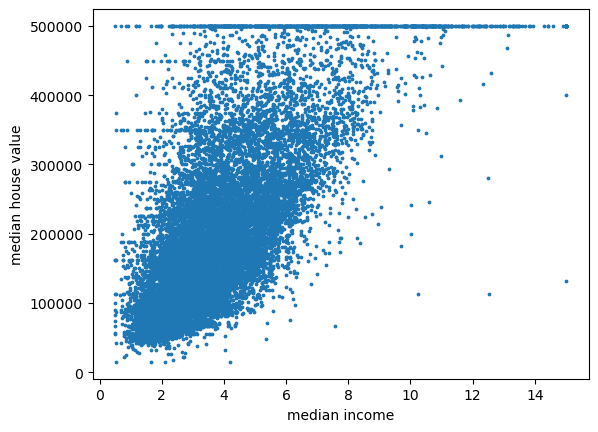

In [112]:
# Scatter plot of median_house_value against median_income
plt.scatter(df['median_income'], df['median_house_value'], s=3)
plt.xlabel('median income')
plt.ylabel('median house value');

Apparently, the house value is capped at 500000.

In [113]:
# Create a new column with the rooms per person
df['rooms_per_person'] = df['total_rooms']/df['population']
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_person
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900,5.529064
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100,6.775908
2,-114.56,33.69,17,720,174,333,117,1.6509,85700,2.162162
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400,2.914563
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500,2.330128


The new column is added at the end.

# <a href=https://seaborn.pydata.org/><img src=https://seaborn.pydata.org/_static/logo-wide-lightbg.svg width=200 align=center></a> Seaborn - just a word on it

Seaborn simply makes quite nice plots. You should check out [their documentation](https://seaborn.pydata.org/). This is one example plot:

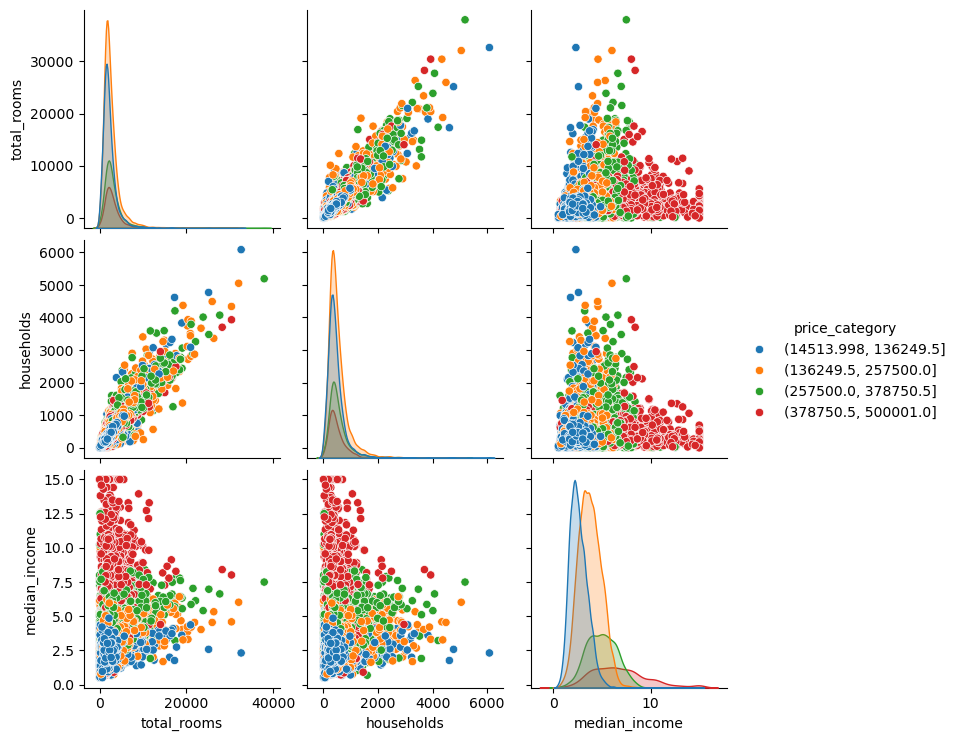

In [114]:
import seaborn as sns
# read the csv we used before
data = pd.read_csv("../datasets/california_housing_train.csv")
# we create a new category feature dividing the house value in 4 ranges
data["price_category"] = pd.cut(data["median_house_value"], 4)
# the actual plot
sns.pairplot(data, vars=["total_rooms", "households", "median_income"], hue="price_category");

# K-Nearest Neighbors

## Excercise 6: Perform a classification using K-nearest neighbors classifier discussed in the lecture.

http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [116]:
# we load the training data from the local virtual machine as well and get a numpy array from it
mnist_train = pd.read_csv("../datasets/mnist_train_small.csv", header=None ).to_numpy()
# the first entry is the digit, the rest of the array contains the pixel values
digits_train = mnist_train[:,0]
images_train = mnist_train[:,1:]
print(digits_train.shape)
print(images_train.shape)

(20000,)
(20000, 784)


This is a 5


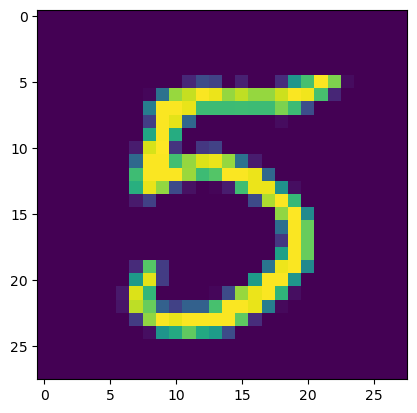

In [117]:
# the images are 28x28 but we will use the flattened array for training because KNN can only handle tabular data
plt.imshow(images_train[1].reshape(28,28));
print(f"This is a {digits_train[1]}")

In [121]:
# we train on some data and then we test on some other data, where would be the joke otherwise?
mnist_test = pd.read_csv("../datasets/mnist_test.csv", header=None ).to_numpy()
digits_test = mnist_test[:,0]
images_test = mnist_test[:,1:]

In [122]:
# import the classifier
from sklearn.neighbors import KNeighborsClassifier

# we use 7 next neighbors (this is rather much)
kn = KNeighborsClassifier(n_neighbors=7)

# for now, we will only use 100 training samples to keep the runtime low
N_samples = 100
X_train = images_train[:N_samples]
y_train = digits_train[:N_samples]
# this trains the KNN classifier. We pass the images and the digits as design matrix and target vector
kn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


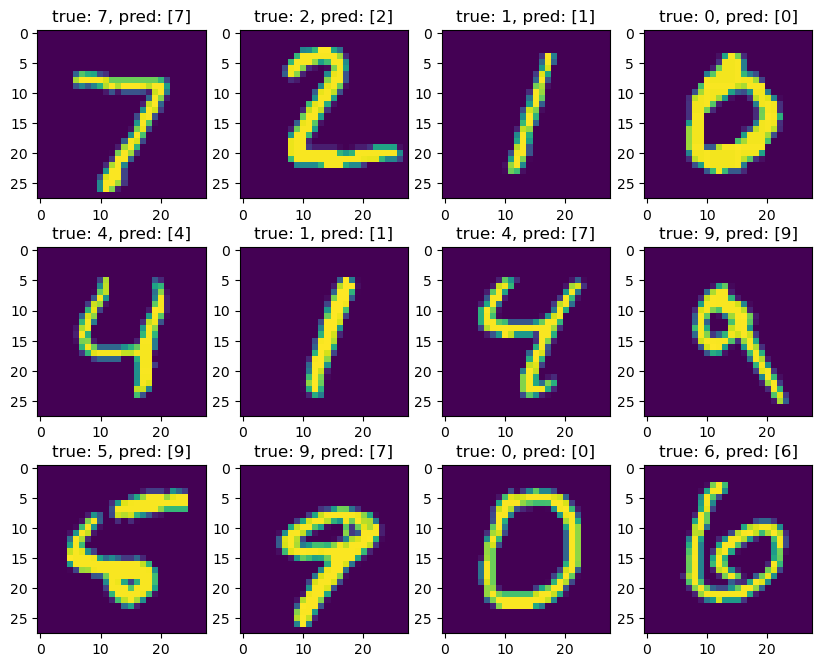

In [123]:
rows    = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10,8))

idx = 0
for r in range(rows):
  for c in range(columns):
      img        = images_test[idx].reshape(1, -1) # the shape needs to be (1, features)
      digit_true = digits_test[idx]
      digit_pred = kn.predict(img)
      axes[r, c].imshow(img.reshape(28,28))
      axes[r, c].set_title(f"true: {digit_true}, pred: {digit_pred}")
      idx += 1

## Exercise 7 - The actual tasks:
- Predict the digits for the whole training and test data set
- Compute the accuracy for both training and test predictions. How much difference is there?
- Plot some examples of misclassified digits.
- How does the performance of the algorithm change with the number of nearest neighbours?

In [124]:
# Digit predictions for both datasets
pred_train = kn.predict(images_train)
pred_test = kn.predict(images_test)

In [125]:
# Accuracy on the training set (the part actually used for training)
acc_train0 = np.count_nonzero(pred_train[:N_samples] == digits_train[:N_samples])/N_samples
print(f'Accuracy on the dataset used for training: {acc_train0*100:.1f}%')

Accuracy on the dataset used for training: 76.0%


In [126]:
# Accuracy on the whole training set
acc_train = np.count_nonzero(pred_train == digits_train)/np.size(digits_train)
print(f'Accuracy on the whole training set: {acc_train*100:.1f}%')

Accuracy on the whole training set: 64.8%


In [127]:
# Accuracy on the test set
acc_test = np.count_nonzero(pred_test == digits_test)/np.size(digits_test)
print(f'Accuracy on the test set: {acc_test*100:.1f}%')

Accuracy on the test set: 66.5%


We can see that the accuracy on the dataset used for training (only the first 100 samples of the training dataset) is around a 10% higher than for the whole training set or the test set. This is because the model is a bit tuned to the dataset to which it was fitted, so it performs better on it than on a random sample.

Overall, we observe an accuracy around 65%.

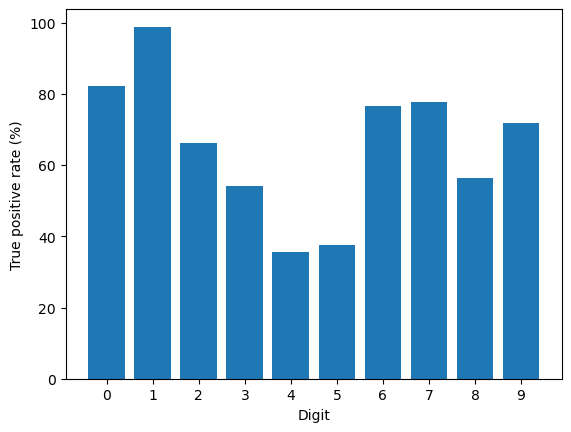

In [128]:
# First I would like to see the true positive rate of the model on each digit
conf_matrix = np.zeros((10, 10))
for i in range(np.size(digits_test)):
  conf_matrix[digits_test[i], pred_test[i]] += 1

TP_rate = []
for i in range(10):
  conf_matrix[i,:] = conf_matrix[i,:]/np.sum(conf_matrix[i,:])*100
  # print(f'TP rate for digit {i}: {conf_matrix[i,i]:.1f}%')
  TP_rate.append(conf_matrix[i,i])

plt.bar(np.arange(10), TP_rate)
plt.xlabel('Digit')
plt.ylabel('True positive rate (%)')
plt.xticks(np.arange(10));

The digits that are best classified with this model are 0 and 1, especially the latter. On the other hand, the digits 4 and 5 are misclassified more than 60% of the times.

In [129]:
# Now I would like to see the digits that are more often mixed up
mask = (conf_matrix>15) & ~np.eye(10, dtype=bool) # digits mixed up more than 15%
indices = np.argwhere(mask)

for i in range(indices.shape[0]):
  i1 = indices[i,0]
  i2 = indices[i,1]
  prob = conf_matrix[i1, i2]
  print(f'A {i1} is misclassified as a {i2} {prob:.1f}% of the times')


A 3 is misclassified as a 1 18.3% of the times
A 4 is misclassified as a 9 40.5% of the times
A 5 is misclassified as a 1 19.7% of the times
A 9 is misclassified as a 7 17.3% of the times


The main confussion comes from classifying a 4 as a 9 (almost half of the times). This makes sense as their shape is very similar.

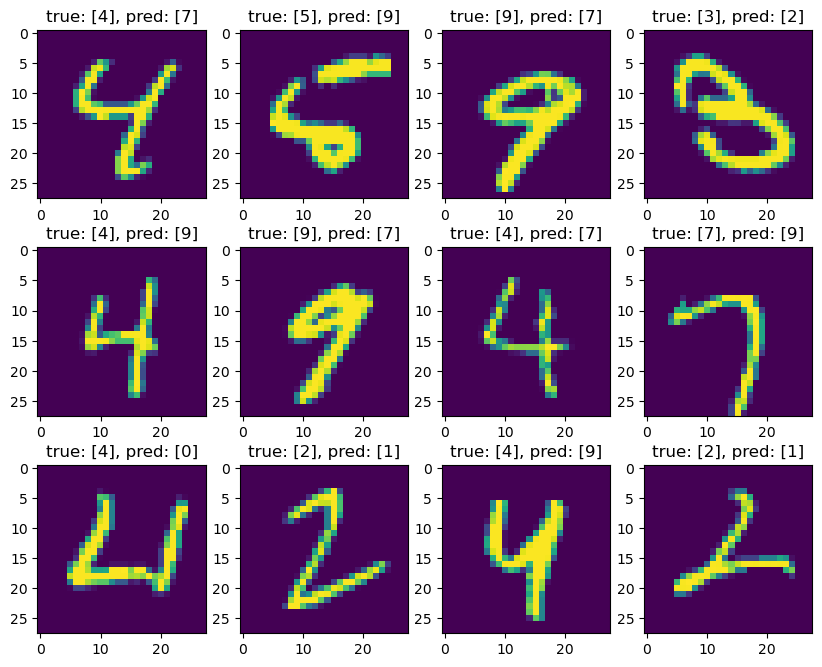

In [130]:
# Now we plot some examples of misclassified digits
indices = np.argwhere(pred_test != digits_test)[:12]

rows    = 3
columns = 4
f, axes = plt.subplots(rows, columns, figsize=(10,8))

idx = 0
for r in range(rows):
  for c in range(columns):
      img        = images_test[indices[idx]].reshape(1, -1) # the shape needs to be (1, features)
      digit_true = digits_test[indices[idx]]
      digit_pred = kn.predict(img)
      axes[r, c].imshow(img.reshape(28,28))
      axes[r, c].set_title(f"true: {digit_true}, pred: {digit_pred}")
      idx += 1

In [131]:
# Let's now change the number of nearest neighbours
N = 20
acc = []

for i in range(1, N+1):
  kn = KNeighborsClassifier(n_neighbors=i)
  kn.fit(X_train, y_train)
  pred_test = kn.predict(images_test)
  acc.append(np.count_nonzero(pred_test == digits_test)/np.size(digits_test))

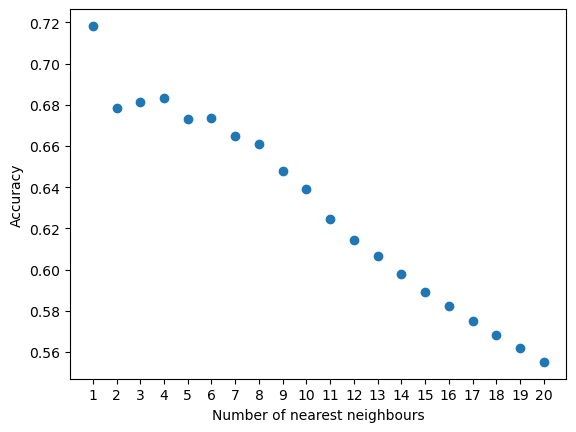

In [132]:
plt.scatter(np.arange(1, N+1), acc)
plt.xlabel('Number of nearest neighbours')
plt.xticks(np.arange(1, N+1))
plt.ylabel('Accuracy');

We observe that the accuracy (measured on the test set) actually decreases as the number of neighbours increases. The best accuracy is obtained if we only look for the nearest neighbour in order to predict the digit.